# Level 2: Automated Event Detection
**Objective**: Implement automated detectors for Apnea, Hypopnea, and Desaturation events based on AASM rules, calculate AHI, and analyze by body position.


In [1]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# Add src to path
sys.path.append('src')
from event_detector import SleepEventDetector

plt.style.use('seaborn-v0_8-whitegrid')


## 1. Load Clean Dataset
Loading the 10 Hz aligned Parquet dataset generated in Level 1.


In [2]:
# Load data
df = pd.read_parquet('../level1_eda/outputs/clean_data.parquet')

# Identify relevant columns
flow_col = [c for c in df.columns if 'nasal' in c.lower()][0]
sao2_col = [c for c in df.columns if 'sao2' in c.lower() or 'spo2' in c.lower()][0]
pos_col = [c for c in df.columns if 'position' in c.lower()][0]

print(f"Loaded {len(df)} samples ({(len(df)/10)/3600:.2f} hours) at 10 Hz.")


Loaded 235900 samples (6.55 hours) at 10 Hz.


## 2. Run Event Detectors
We initialize the `SleepEventDetector` and run Apnea, Hypopnea, and Desaturation detection.


In [3]:
detector = SleepEventDetector(fs=10)

print("Detecting Apneas...")
apneas = detector.detect_apneas(df[flow_col])
print(f"Found {len(apneas)} Apneas.")

print("Detecting Hypopneas...")
hypopneas = detector.detect_hypopneas(df[flow_col], df[sao2_col])
print(f"Found {len(hypopneas)} Hypopneas.")

print("Detecting Desaturations...")
desats = detector.detect_desaturations(df[sao2_col])
print(f"Found {len(desats)} Desaturations.")

# Combine events
all_events = apneas + hypopneas
all_events.sort(key=lambda x: x['start_idx'])


Detecting Apneas...
Found 160 Apneas.
Detecting Hypopneas...


Found 29 Hypopneas.
Detecting Desaturations...
Found 315 Desaturations.


## 3. AHI Report and Positional Analysis
Calculating the Apnea-Hypopnea Index (AHI) and breaking it down by Supine vs Non-supine.


In [4]:
total_duration_s = len(df) / 10.0
report = detector.calculate_ahi(all_events, total_duration_s, df=df, position_col=pos_col)

# Calculate ODI
total_hours = report['Total Hours']
odi = len(desats) / total_hours if total_hours > 0 else 0

print("=== CLINICAL REPORT ===")
print(f"Total Recording Time: {report['Total Hours']:.2f} hours")
print(f"Total Apneas:         {report['Total Apneas']}")
print(f"Total Hypopneas:      {report['Total Hypopneas']}")
print(f"Overall AHI:          {report['AHI']:.2f} events/hr")
print(f"Overall ODI:          {odi:.2f} events/hr")
print("-" * 25)
print(f"Supine Time:          {report.get('Supine Hours', 0):.2f} hours")
print(f"Supine AHI:           {report.get('Supine AHI', 0):.2f} events/hr")
print(f"Non-supine Time:      {report.get('Non-supine Hours', 0):.2f} hours")
print(f"Non-supine AHI:       {report.get('Non-supine AHI', 0):.2f} events/hr")

# Save to file
with open('outputs/ahi_report.md', 'w') as f:
    f.write("# AHI & Positional Report\n\n")
    f.write(f"- **Total Recording Time**: {report['Total Hours']:.2f} hours\n")
    f.write(f"- **Overall AHI**: **{report['AHI']:.2f}**\n")
    f.write(f"- **Overall ODI**: **{odi:.2f}**\n")
    f.write(f"- **Total Apneas**: {report['Total Apneas']}\n")
    f.write(f"- **Total Hypopneas**: {report['Total Hypopneas']}\n\n")
    f.write("## Positional Breakdown\n")
    f.write(f"- **Supine AHI**: {report.get('Supine AHI', 0):.2f} (Time: {report.get('Supine Hours', 0):.2f} hrs)\n")
    f.write(f"- **Non-supine AHI**: {report.get('Non-supine AHI', 0):.2f} (Time: {report.get('Non-supine Hours', 0):.2f} hrs)\n")


=== CLINICAL REPORT ===
Total Recording Time: 6.55 hours
Total Apneas:         160
Total Hypopneas:      29
Overall AHI:          28.84 events/hr
Overall ODI:          48.07 events/hr
-------------------------
Supine Time:          0.00 hours
Supine AHI:           0.00 events/hr
Non-supine Time:      6.55 hours
Non-supine AHI:       28.84 events/hr


## 4. Visualizing Detected Events
We will plot a segment of the data that contains detected events, drawing shaded boxes over them.


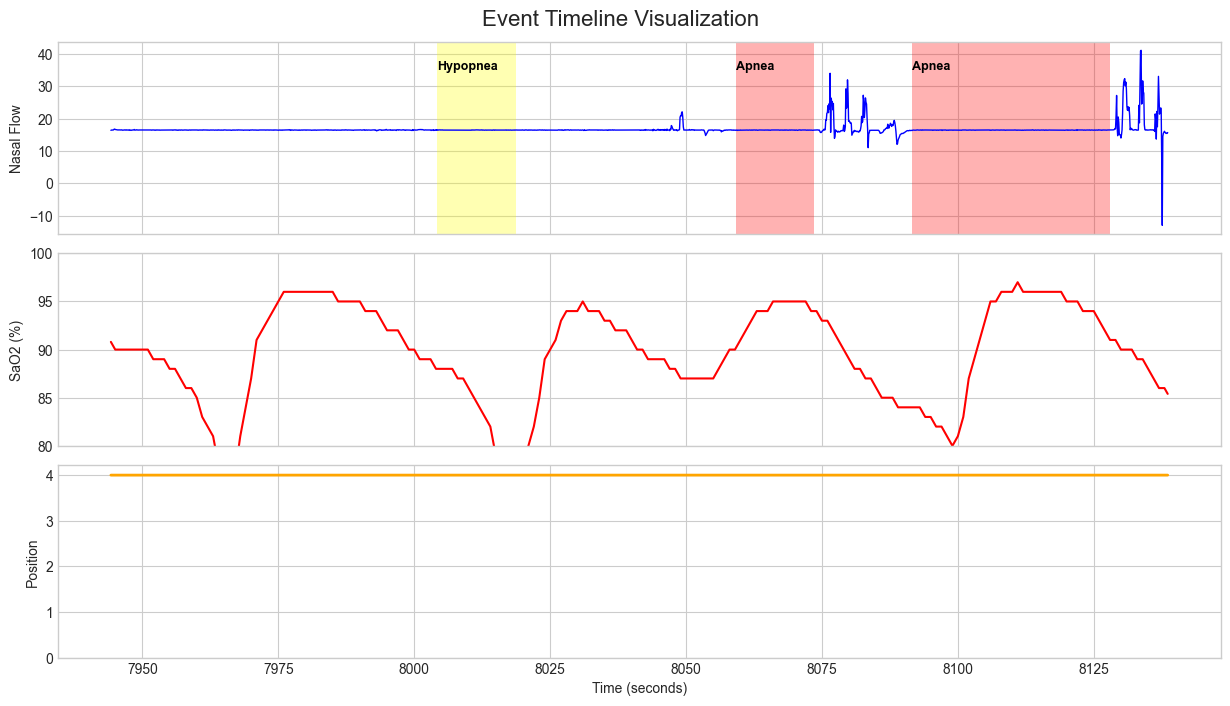

In [5]:
# Find a window that contains at least one apnea or hypopnea
if len(all_events) > 0:
    # Take an event from the middle of the list to ensure it's not at the very edge
    target_event = all_events[len(all_events)//2]
    start_plot_idx = max(0, target_event['start_idx'] - 600) # 60s before
    end_plot_idx = min(len(df), target_event['end_idx'] + 1200) # 120s after
else:
    start_plot_idx = len(df) // 2
    end_plot_idx = start_plot_idx + 1800
    
df_plot = df.iloc[start_plot_idx:end_plot_idx]
time_axis = df_plot.index.total_seconds()

fig, axes = plt.subplots(3, 1, figsize=(15, 8), sharex=True, gridspec_kw={'hspace': 0.1})

# Plot Flow
axes[0].plot(time_axis, df_plot[flow_col], color='blue', linewidth=1)
axes[0].set_ylabel('Nasal Flow')

# Plot SpO2
axes[1].plot(time_axis, df_plot[sao2_col], color='red', linewidth=1.5)
axes[1].set_ylabel('SaO2 (%)')
axes[1].set_ylim(80, 100)

# Plot Position
axes[2].plot(time_axis, df_plot[pos_col], color='orange', linewidth=2)
axes[2].set_ylabel('Position')
axes[2].set_yticks([0,1,2,3,4])
axes[2].set_xlabel('Time (seconds)')

# Draw events
for e in all_events:
    if e['start_idx'] >= start_plot_idx and e['end_idx'] <= end_plot_idx:
        start_t = df.index[e['start_idx']].total_seconds()
        duration_t = df.index[e['end_idx']].total_seconds() - start_t
        
        color = 'red' if e['type'] == 'Apnea' else 'yellow'
        
        # Add shaded region to Flow
        rect = patches.Rectangle((start_t, axes[0].get_ylim()[0]), duration_t, 
                                 axes[0].get_ylim()[1] - axes[0].get_ylim()[0], 
                                 linewidth=0, facecolor=color, alpha=0.3)
        axes[0].add_patch(rect)
        axes[0].text(start_t, axes[0].get_ylim()[1]*0.8, e['type'], color='black', fontsize=9, fontweight='bold')

plt.suptitle('Event Timeline Visualization', y=0.92, fontsize=16)
plt.savefig('outputs/events_timeline.png', bbox_inches='tight')
plt.show()
